# The Causal Relationship Between Economic Activity and CO₂ Emissions: A Panel Data Analysis

## GDP 

In [2]:
import pandas as pd
import requests
import numpy as np
import patchworklib as pw
from plotnine import *
from skimpy import skim
import statsmodels.formula.api as smf
from mizani.formatters import percent_format
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pycountry
from countrycode import countrycode
from functools import reduce  # Import reduce
from datetime import datetime
import datetime as dt
import math


<Figure size 100x100 with 0 Axes>

### DATA CLEANING

#### Importing databases

In [3]:
data_input = '/Users/amh/Desktop/CEU-EDP/DA4/Assignment/DA-4-2405060/data/'

ff_elec_df = pd.read_csv(data_input + "FFelec.csv")
gdpy_ppp = pd.read_csv(data_input + "GDPyPP.csv", skiprows=3)
co2y = pd.read_csv(data_input + 'co2y.csv')
cip = pd.read_csv(data_input + 'cip.csv', encoding='ISO-8859-1') 


#### GDPy_ppp cleaning

In [4]:
gdpy_ppp = gdpy_ppp.drop(columns=['Unnamed: 68'], errors='ignore')
gdpy_ppp.head()



,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,36275.680955,35682.300253,36021.830836,38558.004558,39419.555348,38435.426913,28521.688852,35696.309372,38877.674436,40516.808563
1,Africa Eastern and Southern,AFE,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4052.851526,4076.020565,4074.982133,4085.879143,4088.890953,4073.880522,3861.111238,3934.287267,3974.803045,3967.860937
2,Afghanistan,AFG,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3017.942544,2967.692067,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1992.424394
3,Africa Western and Central,AFW,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4816.917355,4817.800552,4713.515152,4709.645461,4730.823407,4774.412771,4622.731427,4698.926894,4767.383262,4814.611443
4,Angola,AGO,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,10250.592404,9980.929882,9381.809726,9042.117129,8620.214664,8274.542562,7556.967928,7408.126591,7397.486427,7244.893053


In [5]:
# Check the first few rows and the data types of the columns
print(gdpy_ppp.head())
print(gdpy_ppp.dtypes)

# Check if the GDP columns (1960-2023) contain valid values
year_columns = [str(year) for year in range(1960, 2024)]  # From 1960 to 2023
# Convert the year columns to numeric, coercing errors to NaN
gdpy_ppp[year_columns] = gdpy_ppp[year_columns].apply(pd.to_numeric, errors='coerce')

# Melt the DataFrame to long format
gdpy_df = pd.melt(gdpy_ppp, 
                  id_vars=['Country Name', 'Country Code'],  # Keep these columns
                  value_vars=year_columns,  # Specify the year columns explicitly
                  var_name='Year',  # Name for the new column that will hold the years
                  value_name='GDP_PPP')  # Name for the new column with the GDP PPP values


# Display the reshaped DataFrame
gdpy_df.head()


                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name     Indicator Code  1960  \
0  GDP per capita, PPP (constant 2021 internation...  NY.GDP.PCAP.PP.KD   NaN   
1  GDP per capita, PPP (constant 2021 internation...  NY.GDP.PCAP.PP.KD   NaN   
2  GDP per capita, PPP (constant 2021 internation...  NY.GDP.PCAP.PP.KD   NaN   
3  GDP per capita, PPP (constant 2021 internation...  NY.GDP.PCAP.PP.KD   NaN   
4  GDP per capita, PPP (constant 2021 internation...  NY.GDP.PCAP.PP.KD   NaN   

   1961  1962  1963  1964  1965  ...          2014          2015  \
0   NaN   NaN   NaN   NaN   NaN  ...  36275.680955  35682.300253   
1   NaN   NaN   NaN   NaN   NaN  ...   4052.851526   4076.020565   
2   NaN   NaN   NaN   NaN 

,Country Name,Country Code,Year,GDP_PPP
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


### Summary statistics for GDPy and year filtering

In [6]:
gdpy_df.head()

,Country Name,Country Code,Year,GDP_PPP
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


In [7]:
# Convert 'Year' to a numerical format (integer or float)
gdpy_df['Year'] = pd.to_numeric(gdpy_df['Year'], errors='coerce')
gdpy_df = gdpy_df[gdpy_df['Year'] >= 1992]
gdpy_df.describe()

,Year,GDP_PPP
count,8512.000000,7752.000000
mean,2007.500000,20574.475242
std,9.233635,22744.149375
min,1992.000000,510.822823
25%,1999.750000,4332.870647
50%,2007.500000,12154.518059
75%,2015.250000,29165.603785
max,2023.000000,174339.077325


### Dropping countries whose missing variable go above a reccommended threshold

In [8]:
# Define the total number of years (1990 to 2023 inclusive) for threshold
total_years = 2023 - 1992 + 1
#threshold to drop missing variables
threshold = total_years * 0.08

In [9]:
gdpy_df.head()

,Country Name,Country Code,Year,GDP_PPP
8512,Aruba,ABW,1992,35947.372259
8513,Africa Eastern and Southern,AFE,1992,3135.101069
8514,Afghanistan,AFG,1992,NaN
8515,Africa Western and Central,AFW,1992,3228.263516
8516,Angola,AGO,1992,6578.068575


In [10]:
missing_gdpy = gdpy_df['GDP_PPP'].isnull().any()

print("ATTENTION: There are countries with missing GDP per capita values!" 
      if missing_gdpy 
      else "Way to go, there are 0 missing GDP per capita values!")

ATTENTION: There are countries with missing GDP per capita values!


In [11]:
if missing_gdpy: # Only executed if missing values were found in Step 1
    missing_gdpy = (
        gdpy_df[gdpy_df['GDP_PPP'].isnull()]
             .groupby('Country Name')['Year']
             .count()
             .reset_index(name='Missing GDP Count')
    )
    print(
        "These are the countries missing GDP per capita values, and their count:\n" +
        missing_gdpy.to_string(index=False)
    )

    # Filter countries that exceed the missing data threshold
    countries_to_drop_list_gdpy = missing_gdpy.query('`Missing GDP Count` > @threshold')['Country Name'].tolist()

    # Exclude these countries from the DataFrame
    gdpydf_ = gdpy_df[~gdpy_df['Country Name'].isin(countries_to_drop_list_gdpy)]


These are the countries missing GDP per capita values, and their count:
             Country Name  Missing GDP Count
              Afghanistan                  8
           American Samoa                 32
                   Bhutan                  1
   British Virgin Islands                 32
           Cayman Islands                 14
          Channel Islands                 32
                     Cuba                 32
                  Curacao                  8
                 Djibouti                 21
                  Eritrea                 32
            Faroe Islands                 16
         French Polynesia                 32
                Gibraltar                 32
                Greenland                  2
                     Guam                 32
              Isle of Man                 32
Korea, Dem. People's Rep.                 32
                   Kosovo                 16
                  Lebanon                  1
            Liechtenstein   

### Final GDPy Data Frame

In [12]:
gdpydf_ = gdpydf_.sort_values(by=['Country Name', 'Year'])
gdpydf_['Country Name'].nunique()

235

In [13]:
gdpydf_.tail(35)

,Country Name,Country Code,Year,GDP_PPP
16490,Zambia,ZMB,2021,3503.034914
16756,Zambia,ZMB,2022,3585.123791
17022,Zambia,ZMB,2023,3673.484197
8777,Zimbabwe,ZWE,1992,3649.891947
9043,Zimbabwe,ZWE,1993,3634.750494
9309,Zimbabwe,ZWE,1994,3965.730986
9575,Zimbabwe,ZWE,1995,3935.280057
9841,Zimbabwe,ZWE,1996,4271.479930
10107,Zimbabwe,ZWE,1997,4304.406272
10373,Zimbabwe,ZWE,1998,4342.858177


In [14]:
gdpydf_ = gdpydf_.rename(columns={'Country Name': 'Country', 'Country Code': 'Code'})

In [15]:
gdpydf_.isna().sum()

Country    0
Code       0
Year       0
GDP_PPP    8
dtype: int64

## Electricity Generated from Fossil Fuels

In [16]:
ff_elec_df = ff_elec_df.rename(columns={'Entity': 'Country', 'Electricity from fossil fuels - TWh': 'FFelec_val'})

In [17]:
ff_elec_df['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999])

In [18]:
ff_elec_df['Year'] = pd.to_numeric(ff_elec_df['Year'], errors='coerce')



In [19]:
ff_elec_df = ff_elec_df.sort_values(by=['Country', 'Year'])
ff_elec_df.tail(20)

,Country,Year,FFelec_val
6709,Zimbabwe,2003,3.45
6710,Zimbabwe,2004,4.22
6711,Zimbabwe,2005,4.45
6712,Zimbabwe,2006,2.57
6713,Zimbabwe,2007,2.16
6714,Zimbabwe,2008,1.84
6715,Zimbabwe,2009,1.77
6716,Zimbabwe,2010,2.77
6717,Zimbabwe,2011,3.88
6718,Zimbabwe,2012,3.64


### Country Code Mask

In [20]:
ff_elec_df['Country'].unique()

array(['ASEAN (Ember)', 'Afghanistan', 'Africa', 'Africa (EI)',
       'Africa (Ember)', 'Albania', 'Algeria', 'American Samoa', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (Ember)', 'Asia Pacific (EI)', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'CIS (EI)', 'Cambodia', 'Cameroon', 'Canada',
       'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad',
       'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador'

In [21]:
non_country_values = [
    "ASEAN (Ember)", "Latin America and Caribbean (Ember)", "Africa", "High-income countries", 
    "G20 (Ember)", "Europe", "OECD (EI)", "North America", "South America", "Middle East (EI)",
    "Asia", "World", "Non-OECD (EI)", "Africa (Ember)", "European Union (27)", "Pacific Islands", 
    "Caribbean", "North America (EI)", "South and Central America (EI)"
]

# Remove non-country terms (we filter out rows that contain these)
filtered_df = ff_elec_df[~ff_elec_df['Country'].isin(non_country_values)]

In [22]:
 #Apply countrycode to the valid countries
filtered_df['Code'] = countrycode(filtered_df['Country'], origin='country.name', destination='iso3c')

# Handle the non-country rows, and set them as NaN or leave them as-is
ff_elec_df['Code'] = ff_elec_df.apply(
    lambda row: countrycode(row['Country'], origin='country.name', destination='iso3c') 
    if row['Country'] not in non_country_values else None, axis=1
)

# Print the DataFrame
print(ff_elec_df[['Country', 'Code']])

            Country  Code
0     ASEAN (Ember)  None
1     ASEAN (Ember)  None
2     ASEAN (Ember)  None
3     ASEAN (Ember)  None
4     ASEAN (Ember)  None
...             ...   ...
6724       Zimbabwe   ZWE
6725       Zimbabwe   ZWE
6726       Zimbabwe   ZWE
6727       Zimbabwe   ZWE
6728       Zimbabwe   ZWE

[6729 rows x 2 columns]


### Year filtering and Summary Statistics

In [23]:
# Convert 'Year' to a numerical format (integer or float)
ff_elec_df['Year'] = pd.to_numeric(ff_elec_df['Year'], errors='coerce')
ff_elec_df = ff_elec_df[ff_elec_df['Year'] >= 2000]
ff_elec_df.describe()


,Year,FFelec_val
count,5754.000000,5754.000000
mean,2011.216719,519.997140
std,6.761497,1822.884048
min,2000.000000,0.000000
25%,2005.000000,0.350000
50%,2011.000000,4.650000
75%,2017.000000,68.957500
max,2023.000000,17879.410000


In [24]:
ff_elec_df.head(30)

,Country,Year,FFelec_val,Code
0,ASEAN (Ember),2000,305.36,None
1,ASEAN (Ember),2001,327.66,None
2,ASEAN (Ember),2002,356.67,None
3,ASEAN (Ember),2003,381.84,None
4,ASEAN (Ember),2004,418.60,None
5,ASEAN (Ember),2005,443.48,None
6,ASEAN (Ember),2006,460.92,None
7,ASEAN (Ember),2007,488.20,None
8,ASEAN (Ember),2008,504.23,None
9,ASEAN (Ember),2009,520.17,None


In [25]:
ffelec_df = ff_elec_df.dropna(subset=['Code'])

In [26]:
ffelec_df.head()

,Country,Year,FFelec_val,Code
24,Afghanistan,2000,0.17,AFG
25,Afghanistan,2001,0.19,AFG
26,Afghanistan,2002,0.15,AFG
27,Afghanistan,2003,0.28,AFG
28,Afghanistan,2004,0.23,AFG


In [27]:
missing_ffelec = ff_elec_df['FFelec_val'].isnull().any()

print("ATTENTION: There are countries with missing FFelec values!" 
      if missing_ffelec 
      else "Way to go, there are 0 missing FFelec values!")

Way to go, there are 0 missing FFelec values!


In [28]:
if missing_ffelec: # Only executed if missing values were found in Step 1
    missing_ffelec = (
        ff_elec_df[ff_elec_df['FFelec_val'].isnull()]
             .groupby('Country')['Year']
             .count()
             .reset_index(name='Missing FFelec Count')
    )
    print(
        "These are the countries missing FFelec values, and their count:\n" +
        missing_ffelec.to_string(index=False)
    )

    # Filter countries that exceed the missing data threshold
    countries_to_drop_list_ffelec = missing_ffelec.query('`Missing FFelec Count` > @threshold')['Country'].tolist()

    # Exclude these countries from the DataFrame
    ff_elec_df = ff_elec_df[~ff_elec_df['Country'].isin(countries_to_drop_list_ffelec)]


### Issue countries missing before 2000: Imputation 

print(ff_elec_df[ff_elec_df['Year'] == 1992]['Country'].unique())

*********
 Step 1: Define the full range of years
years = np.arange(1992, 2023)

 Step 2: Expand dataset so every country has a row for each year
ff_elec_df_full = (
    ff_elec_df.set_index(['Country', 'Year'])  # Set multi-index for easy reindexing
    .reindex(pd.MultiIndex.from_product([ff_elec_df['Country'].unique(), years], names=['Country', 'Year']))
    .reset_index()
)

Step 3: Assign country codes correctly (fill forward)
ff_elec_df_full = ff_elec_df_full.merge(ff_elec_df[['Country', 'Code']].drop_duplicates(), on='Country', how='left')

Step 4: Apply linear interpolation **ONLY for years before 2000**
def interpolate_pre_2000(group):
    group['FFelec_val'] = group['FFelec_val'].interpolate(method='linear', limit_direction='backward')
    return group


ff_elec_df_full = ff_elec_df_full.groupby('Country', group_keys=False).apply(interpolate_pre_2000)

 Step 5: Verify interpolation worked
ff_elec_df_ = ff_elec_df_full.drop(columns=['Code_x'], errors='ignore').rename(columns={'Code_y': 'Code'})

print(ff_elec_df_.tail(33))  # Check first few rows


### Final FFelecdf (Regressive Linear Interpolation)

ff_elec_df_.head()

## CO2y

In [29]:
co2y.head()

,Entity,Code,Year,Annual CO₂ emissions (per capita)
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123


In [30]:
co2y = co2y.sort_values(by=['Entity', 'Year'])
co2y_ = co2y.rename(columns={'Country Code': 'Code', 'Entity': 'Country', 'Annual CO₂ emissions (per capita)':'val_co2y'})
co2y_


,Country,Code,Year,val_co2y
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123
...,...,...,...,...
26177,Zimbabwe,ZWE,2019,0.672038
26178,Zimbabwe,ZWE,2020,0.547083
26179,Zimbabwe,ZWE,2021,0.645913
26180,Zimbabwe,ZWE,2022,0.648759


In [31]:
co2y_['Year'] = pd.to_numeric(co2y_['Year'], errors='coerce')
co2y_ = co2y_[co2y_['Year'] >= 1992]
co2y_.describe()

,Year,val_co2y
count,7386.000000,7386.000000
mean,2007.512185,5.053267
std,9.227548,6.457618
min,1992.000000,0.000000
25%,2000.000000,0.804425
50%,2008.000000,3.010979
75%,2016.000000,7.193958
max,2023.000000,76.624115


In [32]:
missing_co2y = co2y_['val_co2y'].isnull().any()

print("ATTENTION: There are countries with missing CO2 per capita values" 
      if missing_co2y 
      else "Way to go, there are 0 missing CO2 per capita values!")

Way to go, there are 0 missing CO2 per capita values!


In [33]:
if missing_co2y: # Only executed if missing values were found in Step 1
    missing_co2y = (
        co2y_[co2y_['val_co2y'].isnull()]
        .groupby('Country')['Year']
        .count()
        .reset_index(name='Missing CO2y Count')
    )
    print(
        "These are the countries missing CO2 per capita values, and their count:\n" +
        missing_co2y.to_string(index=False)
    )

    # Filter countries that exceed the missing data threshold
    countries_to_drop_list_FFelec = missing_ffelec.query('`Missing CO2y Count` > @threshold')['Country'].tolist()

    # Exclude these countries from the DataFrame
    ff_elecdf = ff_elec_df[~ff_elec_df['Country'].isin(countries_to_drop_list_FFelec)]


## CIP (confounder)

In [34]:
cip = cip.rename(columns={'countrydesc': 'Country', 'cip':'val_cip', 'year':'Year'})
cip = cip.sort_values(by=['Country', 'Year'])
cip_df = cip[['Year', 'Country', 'val_cip', 'MVAsh']]



In [35]:
missing_cip = cip_df['val_cip'].isnull().any()

print("ATTENTION: There are countries with missing CIP values!" 
      if missing_cip 
      else "Way to go, there are 0 missing CIP values!")

Way to go, there are 0 missing CIP values!


In [36]:
if missing_cip: # Only executed if missing values were found in Step 1
    missing_cip = (
        cip_df[cip_df['val_cip'].isnull()]
        .groupby('Country')['Year']
        .count()
        .reset_index(name='Missing CIP Count')
    )
    print(
        "These are the countries missing CIP per capita values, and their count:\n" +
        missing_cip.to_string(index=False)
    )

    # Filter countries that exceed the missing data threshold
    countries_to_drop_list_cip = missing_cip.query('`Missing CIP Count` > @threshold')['Country'].tolist()

    # Exclude these countries from the DataFrame
    cip_df_ = cip_df[~cip_df['Country'].isin(countries_to_drop_list_cip)]


In [37]:
cip_country = cip_df['Country'].unique().tolist()

In [38]:
def get_country_code_a(cip_country):
    try:
        return pycountry.countries.lookup(cip_country).alpha_3
    except LookupError:
        return None  # Return None if the country isn't found

cip_df['Code'] = cip_df['Country'].apply(get_country_code_a)

In [39]:
cip_df['Year'] = pd.to_numeric(cip_df['Year'], errors='coerce')
cip_df = cip_df[cip_df['Year'] >= 1992]
cip_df.describe()

,Year,val_cip,MVAsh
count,4590.000000,4590.000000,4590.000000
mean,2006.500000,0.073052,0.127371
std,8.656384,0.103950,0.060542
min,1992.000000,0.000000,0.003555
25%,1999.000000,0.009936,0.086151
50%,2006.500000,0.028796,0.124028
75%,2014.000000,0.083523,0.162420
max,2021.000000,0.585056,0.459441


In [40]:
cip_df.head()

,Year,Country,val_cip,MVAsh,Code
439,1992,Afghanistan,0.004567,0.151042,AFG
595,1993,Afghanistan,0.003682,0.118596,AFG
752,1994,Afghanistan,0.002928,0.095724,AFG
908,1995,Afghanistan,0.002548,0.063849,AFG
1061,1996,Afghanistan,0.002685,0.070738,AFG


## check and saving new dfs

In [41]:
gdpydf_['Code'].unique()

array(['AFE', 'AFW', 'ALB', 'DZA', 'AND', 'AGO', 'ATG', 'ARB', 'ARG',
       'ARM', 'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB',
       'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BIH', 'BWA',
       'BRA', 'BRN', 'BGR', 'BFA', 'BDI', 'CPV', 'KHM', 'CMR', 'CAN',
       'CSS', 'CAF', 'CEB', 'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COD',
       'COG', 'CRI', 'CIV', 'HRV', 'CYP', 'CZE', 'DNK', 'DMA', 'DOM',
       'EAR', 'EAS', 'TEA', 'EAP', 'ECU', 'EGY', 'SLV', 'GNQ', 'EST',
       'SWZ', 'ETH', 'EMU', 'ECS', 'TEC', 'ECA', 'EUU', 'FJI', 'FIN',
       'FCS', 'FRA', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GRC', 'GRL',
       'GRD', 'GTM', 'GIN', 'GNB', 'GUY', 'HTI', 'HPC', 'HIC', 'HND',
       'HKG', 'HUN', 'IBD', 'IBT', 'IDB', 'IDX', 'IDA', 'ISL', 'IND',
       'IDN', 'IRN', 'IRQ', 'IRL', 'ISR', 'ITA', 'JAM', 'JPN', 'JOR',
       'KAZ', 'KEN', 'KIR', 'KOR', 'KWT', 'KGZ', 'LAO', 'LTE', 'LCN',
       'LAC', 'TLA', 'LVA', 'LDC', 'LBN', 'LSO', 'LBR', 'LBY', 'LTU',
       'LMY', 'LIC',

In [42]:
co2y_.head(20)

,Country,Code,Year,val_co2y
43,Afghanistan,AFG,1992,0.111609
44,Afghanistan,AFG,1993,0.099507
45,Afghanistan,AFG,1994,0.089462
46,Afghanistan,AFG,1995,0.083051
47,Afghanistan,AFG,1996,0.077131
48,Afghanistan,AFG,1997,0.070678
49,Afghanistan,AFG,1998,0.066728
50,Afghanistan,AFG,1999,0.054890
51,Afghanistan,AFG,2000,0.052017
52,Afghanistan,AFG,2001,0.052706


In [43]:
cip_df.head()

,Year,Country,val_cip,MVAsh,Code
439,1992,Afghanistan,0.004567,0.151042,AFG
595,1993,Afghanistan,0.003682,0.118596,AFG
752,1994,Afghanistan,0.002928,0.095724,AFG
908,1995,Afghanistan,0.002548,0.063849,AFG
1061,1996,Afghanistan,0.002685,0.070738,AFG


In [44]:
# Define base path and output folder
base_path = "/Users/amh/Desktop/CEU-EDP/DA4/Assignment/DA-4-2405060/"
output_model1 = os.path.join(base_path, "Cleaned data model_1")

# Create the output folder if it doesn’t exist
os.makedirs(output_model1, exist_ok=True)

In [45]:


# Dictionary of DataFrames to save
dfs = {
    "gdpydf_cleaned.csv": gdpydf_,
    "co2y_cleaned.csv": co2y_,
    "cip_cleaned.csv": cip_df,
}

# Save each DataFrame as a CSV
for filename, df in dfs.items():
    df.to_csv(os.path.join(output_model1, filename), index=False)

print(f"All cleaned datasets saved to: {output_model1}")

All cleaned datasets saved to: /Users/amh/Desktop/CEU-EDP/DA4/Assignment/DA-4-2405060/Cleaned data model_1


## merging data

In [46]:
# Load all CSV files, dropping 'Country' to prevent duplicates
dfs = [
    pd.read_csv(os.path.join(output_model1, f)).drop(columns=['Country'], errors='ignore')  
    for f in os.listdir(output_model1) if f.endswith(".csv")
]

# Merge all DataFrames on 'Year' and 'Code'
model_df = reduce(lambda left, right: left.merge(right, how="outer", on=["Year", "Code"]), dfs)

print("Merged DataFrame Shape:", model_df.shape)
model_df.head()  # Check the structure

Merged DataFrame Shape: (13278, 6)


,Year,val_cip,MVAsh,Code,GDP_PPP,val_co2y
0,1992,0.004567,0.151042,AFG,NaN,0.111609
1,1993,0.003682,0.118596,AFG,NaN,0.099507
2,1994,0.002928,0.095724,AFG,NaN,0.089462
3,1995,0.002548,0.063849,AFG,NaN,0.083051
4,1996,0.002685,0.070738,AFG,NaN,0.077131


In [47]:
model_df.head()  # Check the structure

,Year,val_cip,MVAsh,Code,GDP_PPP,val_co2y
0,1992,0.004567,0.151042,AFG,NaN,0.111609
1,1993,0.003682,0.118596,AFG,NaN,0.099507
2,1994,0.002928,0.095724,AFG,NaN,0.089462
3,1995,0.002548,0.063849,AFG,NaN,0.083051
4,1996,0.002685,0.070738,AFG,NaN,0.077131


In [48]:
missing_summary = model_df.isnull().sum()
print("Missing Values per Column:\n", missing_summary)


Missing Values per Column:
 Year           0
val_cip     4188
MVAsh       4188
Code        4832
GDP_PPP     5766
val_co2y    1572
dtype: int64


In [49]:
# Count missing values per country (excluding 'Code' itself)
missing_counts = model_df.groupby("Code").apply(lambda x: x.isnull().sum()).drop(columns=["Code"], errors="ignore")

# Find countries exceeding the threshold
countries_to_drop = missing_counts[missing_counts.max(axis=1) > threshold].index.tolist()

# Drop those countries
model_df = model_df[~model_df["Code"].isin(countries_to_drop)]

print(f"Dropped {len(countries_to_drop)} countries with too many missing values.")

Dropped 127 countries with too many missing values.


In [50]:
missing_by_country = model_df.groupby("Code").apply(lambda x: x.isnull().sum().sum()).reset_index(name="Total Missing Values")
missing_by_country = missing_by_country.sort_values(by="Total Missing Values", ascending=False)

print("Countries with the most missing values:\n", missing_by_country.head(10))

Countries with the most missing values:
     Code  Total Missing Values
72   LBN                     5
121  SYR                     5
124  TON                     5
0    AGO                     4
93   NGA                     4
88   MUS                     4
89   MWI                     4
90   MYS                     4
91   NAM                     4
92   NER                     4


In [51]:
model_df = model_df.dropna(subset=["Code"])
model_df = model_df[model_df["Year"] <= 2021]



In [52]:
model_df.tail(30)

,Year,val_cip,MVAsh,Code,GDP_PPP,val_co2y
9060,1992,0.014643,0.185110,ZWE,3649.891947,1.560576
9061,1993,0.014999,0.178434,ZWE,3634.750494,1.476200
9062,1994,0.015491,0.173066,ZWE,3965.730986,1.598672
9063,1995,0.015621,0.160310,ZWE,3935.280057,1.368377
9064,1996,0.015810,0.167533,ZWE,4271.479930,1.334806
9065,1997,0.015798,0.163869,ZWE,4304.406272,1.222621
9066,1998,0.015570,0.157590,ZWE,4342.858177,1.218485
9067,1999,0.013292,0.156196,ZWE,4238.195198,1.334423
9068,2000,0.011147,0.148261,ZWE,4071.022001,1.161661
9069,2001,0.008210,0.139000,ZWE,4102.086705,1.044840


# INITIAL DATA VISUALISATION

### Scatter plot with Regression Line 

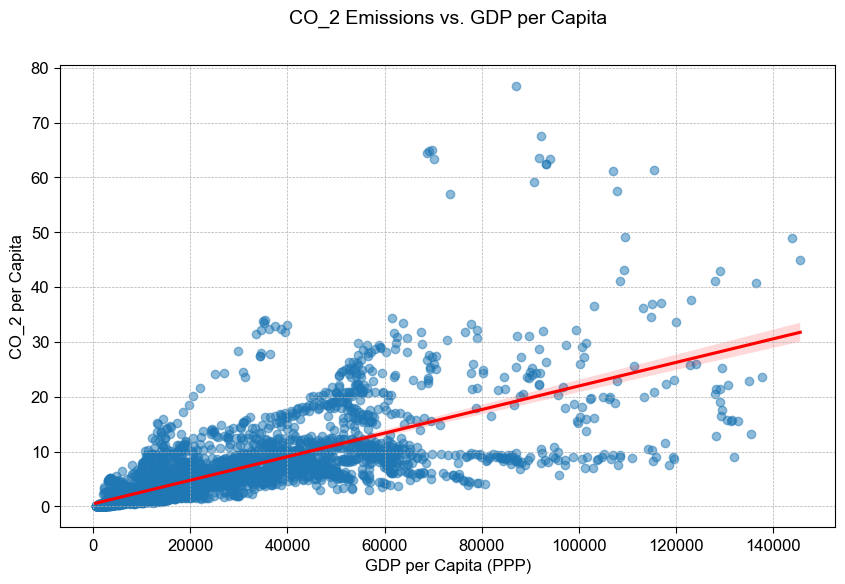

In [53]:
plt.figure(figsize=(10, 6))
sns.regplot(data=model_df, x="GDP_PPP", y="val_co2y", scatter_kws={"alpha":0.5}, line_kws={"color":"red"})

#plt.xscale("log")
#plt.yscale("log")

plt.xlabel("GDP per Capita (PPP)")
plt.ylabel("CO_2 per Capita")
plt.title("CO_2 Emissions vs. GDP per Capita", fontsize=14, pad=30)  # Increase pad value

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

### Scatterplot all countries 2005

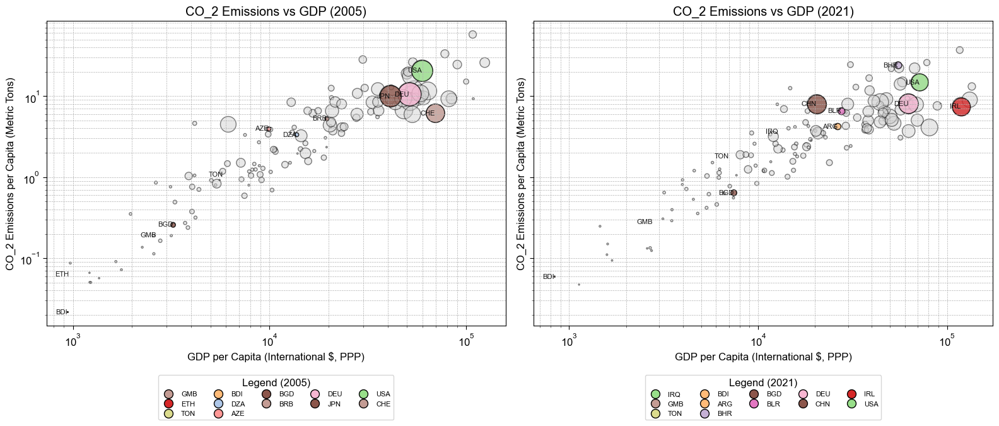

In [54]:
import math

# -----------------------
# 1) HELPER FUNCTIONS
# -----------------------
def is_gray(color, threshold=0.05):
    """
    Determines if a color tuple (R, G, B) is 'close' to gray.
    threshold=0.05 means all channels are nearly equal.
    """
    r, g, b = color
    avg = (r + g + b) / 3
    # sum of absolute differences from the average
    diff_sum = abs(r - avg) + abs(g - avg) + abs(b - avg)
    return diff_sum < threshold

def categorize_cip(value, low_thresh, high_thresh):
    """Categorizes val_cip into 'Low', 'Medium', or 'High' based on two thresholds."""
    if value <= low_thresh:
        return "Low"
    elif value <= high_thresh:
        return "Medium"
    else:
        return "High"

# -----------------------
# 2) PREPARE DATA
# -----------------------
year_2005 = 2005
last_year = model_df["Year"].max()

df_2005 = model_df[model_df["Year"] == year_2005].copy()
df_last = model_df[model_df["Year"] == last_year].copy()

# Determine thresholds for CIP categories
low_thresh = model_df["val_cip"].quantile(0.33)
high_thresh = model_df["val_cip"].quantile(0.67)

df_2005["Category"] = df_2005["val_cip"].apply(categorize_cip, args=(low_thresh, high_thresh))
df_last["Category"] = df_last["val_cip"].apply(categorize_cip, args=(low_thresh, high_thresh))

# -----------------------
# 3) CREATE NON-GRAY PALETTE
# -----------------------
countries = model_df["Code"].unique()
num_countries = len(countries)

# Ask for more colors than needed, to ensure we can skip the grays
expanded_colors = sns.color_palette("tab20", num_countries * 2)

# Filter out any color close to gray
filtered_colors = [c for c in expanded_colors if not is_gray(c)]

# Slice exactly the number of countries we need (if we have enough left)
filtered_colors = filtered_colors[:num_countries]

# Map each country to a distinct non-gray color
color_map = dict(zip(countries, filtered_colors))

# Adjust bubble scaling: CIP is an index
scaling_factor = df_2005["val_cip"].max() / 700  # Larger denominator => smaller bubbles

# -----------------------
# 4) PLOTTING FUNCTION
# -----------------------
def plot_scatter(df, year, ax):
    """
    Plots all points in light grey, then highlights up to 3 extremes (Low, Medium, High)
    using the color_map for each country.
    """
    # Plot all points in light grey
    ax.scatter(
        df["GDP_PPP"],
        df["val_co2y"],
        s=df["val_cip"] / scaling_factor,
        color="lightgrey",
        alpha=0.5,
        edgecolor="black"
    )
    
    highlighted = pd.DataFrame()
    
    # For each CIP category, select up to 3 extremes
    for cat in ["Low", "Medium", "High"]:
        sub = df[df["Category"] == cat]
        if cat == "Low":
            # Take 3 with the smallest val_cip
            sub_highlight = sub.sort_values("val_cip").head(4)
        elif cat == "High":
            # Take 3 with the largest val_cip
            sub_highlight = sub.sort_values("val_cip", ascending=False).head(4)
        else:
            # Medium: just take first 3 (or define another rule)
            sub_highlight = sub.head(4)
        
        highlighted = pd.concat([highlighted, sub_highlight])
        
        # Overlay highlighted points with each country's unique non-gray color
        for _, row in sub_highlight.iterrows():
            ax.scatter(
                row["GDP_PPP"],
                row["val_co2y"],
                s=row["val_cip"] / scaling_factor,
                color=color_map[row["Code"]],
                alpha=0.8,
                edgecolor="black"
            )
    
    # Label the highlighted points
    for _, row in highlighted.iterrows():
        ax.text(
            row["GDP_PPP"],
            row["val_co2y"],
            row["Code"],
            fontsize=8,
            ha="right",
            va="center",
            alpha=0.9
        )
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GDP per Capita (International $, PPP)")
    ax.set_ylabel("CO_2 Emissions per Capita (Metric Tons)")
    ax.set_title(f"CO_2 Emissions vs GDP ({year})")    

    # Add gridlines (as per your request)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    return highlighted


# -----------------------
# 5) MAKE THE SUBPLOTS
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

highlighted_2005 = plot_scatter(df_2005, year_2005, axes[0])
highlighted_last = plot_scatter(df_last, last_year, axes[1])

# -----------------------
# 6) ADDING SEPARATE LEGENDS FOR EACH YEAR
# -----------------------

def add_legend(ax, highlighted_df, title):
    """Creates a subplot-specific legend."""
    legend_handles = []
    legend_labels = []
    
    for _, row in highlighted_df.iterrows():
        handle = plt.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=color_map[row["Code"]],
            markersize=10,
            markeredgecolor="black"
        )
        legend_handles.append(handle)
        legend_labels.append(row["Code"])

    ax.legend(legend_handles, legend_labels, title=title, loc="upper center",
              bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=8, frameon=True)

# Add legends below each subplot
add_legend(axes[0], highlighted_2005, f"Legend ({year_2005})")
add_legend(axes[1], highlighted_last, f"Legend ({last_year})")

plt.tight_layout()
plt.show()


### LINEAR REGRESSION

In [55]:
model_df["log_gdpy"] = np.log(model_df["GDP_PPP"])
model_df["log_co2y"] = np.log(model_df["val_co2y"])

In [56]:
# Log-Log (Log GDP & Log CO₂, but keep CIP in levels)
model_log_log = smf.ols("log_co2y ~ log_gdpy + val_cip", data=model_df).fit()
print("\n--- Log-Log OLS ---\n", model_log_log.summary())


--- Log-Log OLS ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     9802.
Date:                Sun, 16 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:05:43   Log-Likelihood:                -4044.5
No. Observations:                4110   AIC:                             8095.
Df Residuals:                    4107   BIC:                             8114.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.8808      0.0

- 2005 AND LAST YEAR


In [57]:
# Subset the data for 2005
data_2005 = model_df[model_df["Year"] == 2005]

# Run the cross-sectional OLS (using our preferred transformation—say, log CO₂, level GDP, and CIP in levels)
model_cs_2005 = smf.ols(" log_co2y ~ log_gdpy + val_cip", data=data_2005).fit()
print("\n--- Cross-Section OLS for 2005 ---\n", model_cs_2005.summary())




--- Cross-Section OLS for 2005 ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     424.9
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           9.75e-59
Time:                        15:05:43   Log-Likelihood:                -123.66
No. Observations:                 137   AIC:                             253.3
Df Residuals:                     134   BIC:                             262.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -1

In [58]:
# Assume the last available year is the maximum year in your dataset
last_year = model_df["Year"].max()
data_last = model_df[model_df["Year"] == last_year]

model_cs_last = smf.ols("log_co2y ~ log_gdpy + val_cip", data=data_last).fit()
print("\n--- Cross-Section OLS for the Last Year (" + str(last_year) + ") ---\n", model_cs_last.summary())



--- Cross-Section OLS for the Last Year (2021) ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     292.6
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           1.28e-49
Time:                        15:05:43   Log-Likelihood:                -119.37
No. Observations:                 137   AIC:                             244.7
Df Residuals:                     134   BIC:                             253.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [91]:
model_df['Code'].nunique()

137

## Difference in Difference

### No Lags

In [59]:
# Sort the data
model_df = model_df.sort_values(["Code", "Year"])

# Create difference variables within each country
model_df["d_log_co2"] = model_df.groupby("Code")["log_co2y"].diff()
model_df["d_log_gdp"] = model_df.groupby("Code")["log_gdpy"].diff()
model_df["d_val_cip"] = model_df.groupby("Code")["val_cip"].diff()

# Create a time trend variable (for example, use the actual Year or a sequential count)
model_df["time_trend"] = model_df["Year"]

# Drop missing differences (the first observation per country will be NA)
data_diff = model_df.dropna(subset=["d_log_co2", "d_log_gdp", "d_val_cip"])

# Run the first difference OLS with time trend
model_fd_no_lag = smf.ols("d_log_co2 ~ d_log_gdp + d_val_cip + time_trend", data=data_diff).fit()
print("\n--- First Difference Model (No Lags) ---\n", model_fd_no_lag.summary())



--- First Difference Model (No Lags) ---
                             OLS Regression Results                            
Dep. Variable:              d_log_co2   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     150.7
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           1.79e-92
Time:                        15:05:43   Log-Likelihood:                 3325.0
No. Observations:                3973   AIC:                            -6642.
Df Residuals:                    3969   BIC:                            -6617.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

### Lagged regressions

In [60]:
# Create 2-year lagged differences (for each country)
data_diff["d_log_gdp_lag2"] = data_diff.groupby("Code")["d_log_gdp"].shift(2)
data_diff["d_val_cip_lag2"] = data_diff.groupby("Code")["d_val_cip"].shift(2)

# Drop rows with missing lagged values
data_diff_lag2 = data_diff.dropna(subset=["d_log_gdp_lag2", "d_val_cip_lag2"])

# Run the regression with 2-year lags and time trend
model_fd_lag2 = smf.ols("d_log_co2 ~ d_log_gdp_lag2 + d_val_cip_lag2 + time_trend", data=data_diff_lag2).fit()
print("\n--- First Difference Model (2-Year Lags) ---\n", model_fd_lag2.summary())



--- First Difference Model (2-Year Lags) ---
                             OLS Regression Results                            
Dep. Variable:              d_log_co2   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     9.989
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           1.48e-06
Time:                        15:05:43   Log-Likelihood:                 3250.9
No. Observations:                3699   AIC:                            -6494.
Df Residuals:                    3695   BIC:                            -6469.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [61]:
# Create 6-year lagged differences
data_diff["d_log_gdp_lag6"] = data_diff.groupby("Code")["d_log_gdp"].shift(6)
data_diff["d_val_cip_lag6"] = data_diff.groupby("Code")["d_val_cip"].shift(6)

# Drop rows with missing lagged values
data_diff_lag6 = data_diff.dropna(subset=["d_log_gdp_lag6", "d_val_cip_lag6"])

# Run the regression with 6-year lags and time trend
model_fd_lag6 = smf.ols("d_log_co2 ~ d_log_gdp_lag6 + d_val_cip_lag6 + time_trend", data=data_diff_lag6).fit()
print("\n--- First Difference Model (6-Year Lags) ---\n", model_fd_lag6.summary())



--- First Difference Model (6-Year Lags) ---
                             OLS Regression Results                            
Dep. Variable:              d_log_co2   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     7.656
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           4.26e-05
Time:                        15:05:43   Log-Likelihood:                 2966.9
No. Observations:                3151   AIC:                            -5926.
Df Residuals:                    3147   BIC:                            -5902.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

### FE_model

In [62]:
model_fe = smf.ols("log_co2y ~ log_gdpy + val_cip + C(Code) + C(Year)", data=model_df).fit()
print("\n--- Fixed Effects Model (Country & Time FE) ---\n", model_fe.summary())



--- Fixed Effects Model (Country & Time FE) ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     1241.
Date:                Sun, 16 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:05:43   Log-Likelihood:                 532.99
No. Observations:                4110   AIC:                            -730.0
Df Residuals:                    3942   BIC:                             332.0
Df Model:                         167                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [63]:
model_df.describe()

,Year,val_cip,MVAsh,GDP_PPP,val_co2y,log_gdpy,log_co2y,d_log_co2,d_log_gdp,d_val_cip,time_trend
count,4110.000000,4110.000000,4110.000000,4110.000000,4110.000000,4110.000000,4110.000000,3973.000000,3973.000000,3973.000000,4110.000000
mean,2006.500000,0.074260,0.128237,23768.989306,5.575914,9.506708,0.862943,0.006574,0.018443,-0.000262,2006.500000
std,8.656495,0.104491,0.059441,24592.513622,7.267777,1.162745,1.555576,0.110605,0.054750,0.006188,8.656495
min,1992.000000,0.000000,0.004294,510.822823,0.021731,6.236023,-3.829014,-1.336938,-0.675855,-0.060332,1992.000000
25%,1999.000000,0.010469,0.088395,5808.712072,0.945214,8.667114,-0.056344,-0.036173,0.000396,-0.001252,1999.000000
50%,2006.500000,0.029622,0.125301,14211.168763,3.307873,9.561783,1.196305,0.006678,0.021295,-0.000012,2006.500000
75%,2014.000000,0.086333,0.162285,35623.602645,7.826316,10.480764,2.057492,0.050950,0.042515,0.001176,2014.000000
max,2021.000000,0.585056,0.459441,145591.019357,76.624115,11.888557,4.338912,1.545381,0.651186,0.059360,2021.000000


## VIsualising trend



In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.ticker as ticker

# If you are in an interactive environment and want to speed things up:
plt.ioff()  # turn interactive mode off

# Reset index if necessary
model_df = model_df.reset_index(drop=True)

# Get unique sorted country codes
countries = sorted(model_df["Code"].unique())
num_countries = len(countries)

# Use a pleasing color palette (here using "tab20")
colors = sns.color_palette("tab20", num_countries)
# Map each country code to a unique color
color_map = dict(zip(countries, colors))

# Set up grid layout: 4 columns
cols = 4  
rows = math.ceil(num_countries / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for i, (code, color) in enumerate(zip(countries, colors)):
    ax1 = axes[i]
    country_data = model_df[model_df["Code"] == code]
    
    # Plot CO₂ per capita on primary axis
    sns.lineplot(data=country_data, x="Year", y="val_co2y", ax=ax1, color=color, label="CO_2 per Capita")
    ax1.set_ylabel("CO_2 per Capita (Metric Tons)", color=color)
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(4))  # Limit number of x ticks

    # Create twin axis for GDP per capita
    ax2 = ax1.twinx()
    sns.lineplot(data=country_data, x="Year", y="GDP_PPP", ax=ax2, color=color, linestyle="dashed", label="GDP per Capita")
    ax2.set_ylabel("GDP per Capita (PPP, Constant Prices)", color=color)
    ax2.tick_params(axis="y", labelcolor=color)
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(4))  # Limit number of y ticks

    ax1.set_title(code)
    ax1.set_xlabel("Year")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# If you're done with interactive plotting, you can switch back on:
plt.ion()


- Fixed Effect Visualisation



In [65]:

# Compute predictions from your fixed effects model (model_fe)
# model_fe should be your fitted fixed effects regression from smf.ols(..., data=model_df)
model_df["pred_log_co2"] = model_fe.predict(model_df)

# Get sorted unique country codes from the "Code" column
countries = sorted(model_df["Code"].unique())
num_countries = len(countries)

# Use a pleasing palette (e.g., "tab20") and assign a unique color to each country
colors = sns.color_palette("tab20", num_countries)
color_map = dict(zip(countries, colors))

# Set up a grid of subplots (here, 4 columns)
cols = 4  
rows = math.ceil(num_countries / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

# Loop over each country, plot actual and predicted log CO₂ values over time
for i, code in enumerate(countries):
    ax = axes[i]
    # Filter and sort data for the current country by Year
    country_data = model_df[model_df["Code"] == code].sort_values("Year")
    
    # Plot the actual log CO₂ values (solid line with circle markers)
    ax.plot(country_data["Year"], country_data["log_co2y"], 
            label="Actual", color=color_map[code], linestyle='-', marker='o')
    # Plot the predicted log CO₂ values (dashed line with cross markers)
    ax.plot(country_data["Year"], country_data["pred_log_co2"], 
            label="Predicted", color=color_map[code], linestyle='--', marker='x')
    
    ax.set_title(code)
    ax.set_xlabel("Year")
    ax.set_ylabel("log(CO_2 per Capita)")
    ax.legend(fontsize=8)

# Remove any unused subplots if the grid has extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Time series

In [66]:
# Calculate predicted values for 2005 and last year using the regression coefficients
data_2005["predicted_log_co2y"] = model_cs_2005.predict(data_2005)
data_last["predicted_log_co2y"] = model_cs_last.predict(data_last)

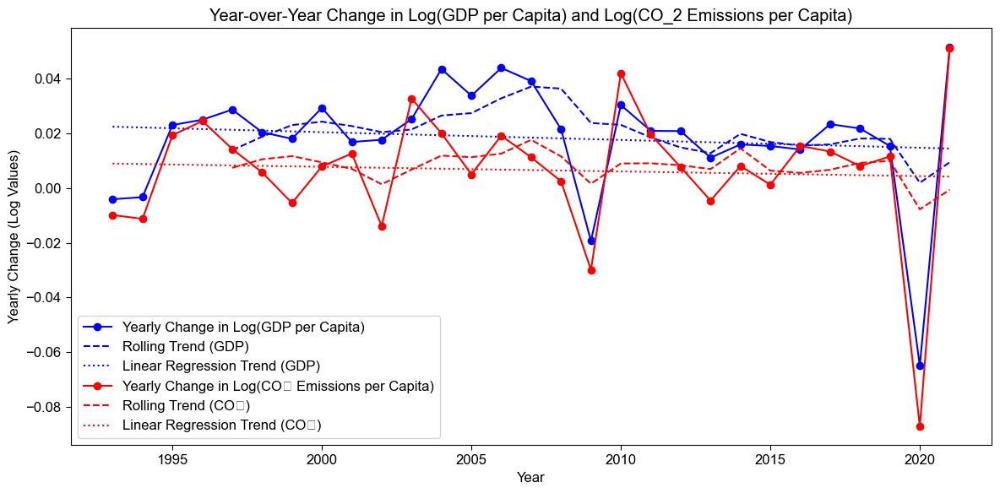

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Calculate Year-over-Year (YoY) changes for log_gdpy and log_co2y
model_df['dlog_gdpy'] = model_df.groupby('Code')['log_gdpy'].diff()
model_df['dlog_co2y'] = model_df.groupby('Code')['log_co2y'].diff()

# Group by Year and calculate the mean yearly change for each year
yearly_changes = model_df.groupby('Year')[['dlog_gdpy', 'dlog_co2y']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 5  # You can adjust the window size (5 years as an example)
yearly_changes['rolling_trend_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_co2y'] = yearly_changes['dlog_co2y'].rolling(window=rolling_window).mean()

# --- Linear Regression Trend Line ---
# Aligning data to avoid misalignment issue
yearly_changes = yearly_changes.dropna(subset=['dlog_gdpy', 'dlog_co2y'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_gdpy = yearly_changes['dlog_gdpy']
y_co2y = yearly_changes['dlog_co2y']

# Perform linear regression for both variables
reg_gdpy = LinearRegression().fit(X, y_gdpy)
reg_co2y = LinearRegression().fit(X, y_co2y)

# Get the regression lines
yearly_changes['regression_trend_gdpy'] = reg_gdpy.predict(X)
yearly_changes['regression_trend_co2y'] = reg_co2y.predict(X)

# Plotting the changes and trends
plt.figure(figsize=(12, 6))

# Plot the yearly change in log_gdpy
plt.plot(yearly_changes.index, yearly_changes['dlog_gdpy'], label="Yearly Change in Log(GDP per Capita)", color='blue', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_gdpy'], label="Rolling Trend (GDP)", color='blue', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_gdpy'], label="Linear Regression Trend (GDP)", color='blue', linestyle=':')

# Plot the yearly change in log_co2y
plt.plot(yearly_changes.index, yearly_changes['dlog_co2y'], label="Yearly Change in Log(CO₂ Emissions per Capita)", color='red', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_co2y'], label="Rolling Trend (CO₂)", color='red', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_co2y'], label="Linear Regression Trend (CO₂)", color='red', linestyle=':')

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Yearly Change (Log Values)")
plt.title("Year-over-Year Change in Log(GDP per Capita) and Log(CO_2 Emissions per Capita)")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


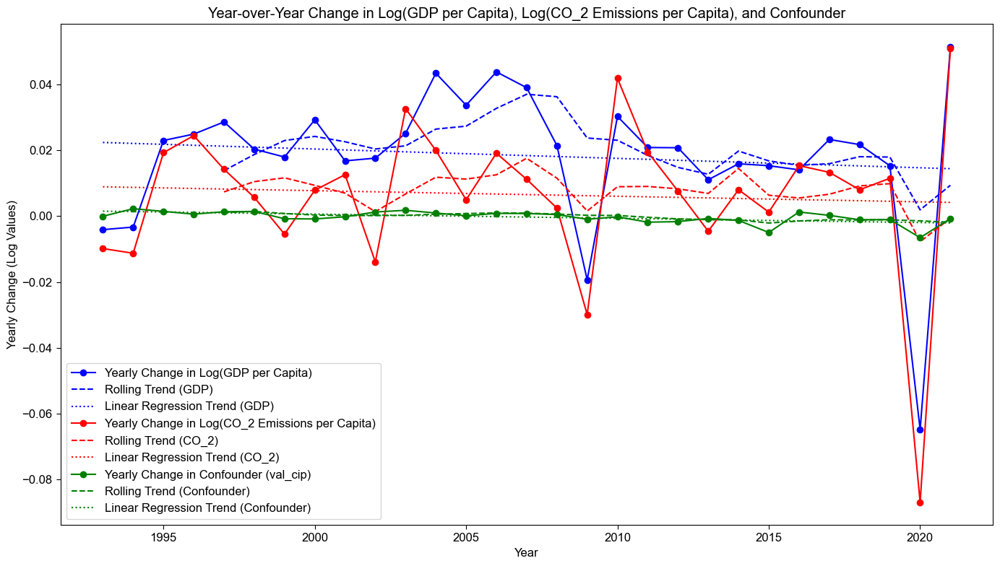

In [68]:
from sklearn.linear_model import LinearRegression

# Calculate Year-over-Year (YoY) changes for log_gdpy, log_co2y, and val_cip
model_df['dlog_gdpy'] = model_df.groupby('Code')['log_gdpy'].diff()
model_df['dlog_co2y'] = model_df.groupby('Code')['log_co2y'].diff()
model_df['dval_cip'] = model_df.groupby('Code')['val_cip'].diff()  # YoY change for the confounder

# Group by Year and calculate the mean yearly change for each year
yearly_changes = model_df.groupby('Year')[['dlog_gdpy', 'dlog_co2y', 'dval_cip']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 5  # You can adjust the window size (5 years as an example)
yearly_changes['rolling_trend_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_co2y'] = yearly_changes['dlog_co2y'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_cip'] = yearly_changes['dval_cip'].rolling(window=rolling_window).mean()  # Rolling trend for confounder

# --- Linear Regression Trend Line ---
# Aligning data to avoid misalignment issue
yearly_changes = yearly_changes.dropna(subset=['dlog_gdpy', 'dlog_co2y', 'dval_cip'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_gdpy = yearly_changes['dlog_gdpy']
y_co2y = yearly_changes['dlog_co2y']
y_cip = yearly_changes['dval_cip']  # Confounder

# Perform linear regression for all variables
reg_gdpy = LinearRegression().fit(X, y_gdpy)
reg_co2y = LinearRegression().fit(X, y_co2y)
reg_cip = LinearRegression().fit(X, y_cip)  # Regression for confounder

# Get the regression lines
yearly_changes['regression_trend_gdpy'] = reg_gdpy.predict(X)
yearly_changes['regression_trend_co2y'] = reg_co2y.predict(X)
yearly_changes['regression_trend_cip'] = reg_cip.predict(X)  # Regression trend for confounder

# Plotting the changes and trends
plt.figure(figsize=(14, 8))

# Plot the yearly change in log_gdpy
plt.plot(yearly_changes.index, yearly_changes['dlog_gdpy'], label="Yearly Change in Log(GDP per Capita)", color='blue', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_gdpy'], label="Rolling Trend (GDP)", color='blue', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_gdpy'], label="Linear Regression Trend (GDP)", color='blue', linestyle=':')

# Plot the yearly change in log_co2y
plt.plot(yearly_changes.index, yearly_changes['dlog_co2y'], label="Yearly Change in Log(CO_2 Emissions per Capita)", color='red', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_co2y'], label="Rolling Trend (CO_2)", color='red', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_co2y'], label="Linear Regression Trend (CO_2)", color='red', linestyle=':')

# Plot the yearly change in val_cip (confounder)
plt.plot(yearly_changes.index, yearly_changes['dval_cip'], label="Yearly Change in Confounder (val_cip)", color='green', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_cip'], label="Rolling Trend (Confounder)", color='green', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_cip'], label="Linear Regression Trend (Confounder)", color='green', linestyle=':')

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Yearly Change (Log Values)")
plt.title("Year-over-Year Change in Log(GDP per Capita), Log(CO_2 Emissions per Capita), and Confounder")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

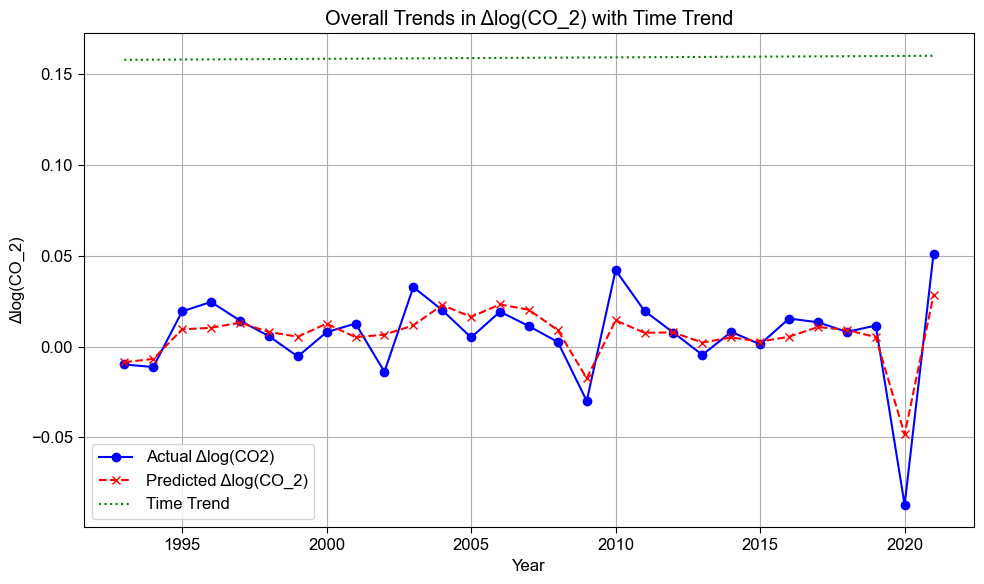

In [69]:
# Extract the time trend coefficient from the regression model
time_trend_coef = model_fd_no_lag.params["time_trend"]

# Create a time trend variable for plotting
data_diff["time_trend_values"] = time_trend_coef * data_diff["time_trend"]

# Compute predicted values from the regression model
data_diff["pred_d_log_co2"] = model_fd_no_lag.predict(data_diff)

# Aggregate the actual and predicted CO₂ values by Year
overall_trends = data_diff.groupby("Year").agg(
    actual_d_log_co2=("d_log_co2", "mean"),
    predicted_d_log_co2=("pred_d_log_co2", "mean"),
    time_trend_values=("time_trend_values", "mean")
).reset_index()

# Plot the overall trends
plt.figure(figsize=(10, 6))

# Plot the actual CO₂ values (solid line with circle markers)
plt.plot(overall_trends["Year"], overall_trends["actual_d_log_co2"], 
         label="Actual Δlog(CO2)", color="blue", linestyle='-', marker='o')

# Plot the predicted CO₂ values (dashed line with cross markers)
plt.plot(overall_trends["Year"], overall_trends["predicted_d_log_co2"], 
         label="Predicted Δlog(CO_2)", color="red", linestyle='--', marker='x')

# Plot the time trend (dotted line)
plt.plot(overall_trends["Year"], overall_trends["time_trend_values"], 
         label="Time Trend", color="green", linestyle=':', marker='')

plt.title("Overall Trends in Δlog(CO_2) with Time Trend")
plt.xlabel("Year")
plt.ylabel("Δlog(CO_2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

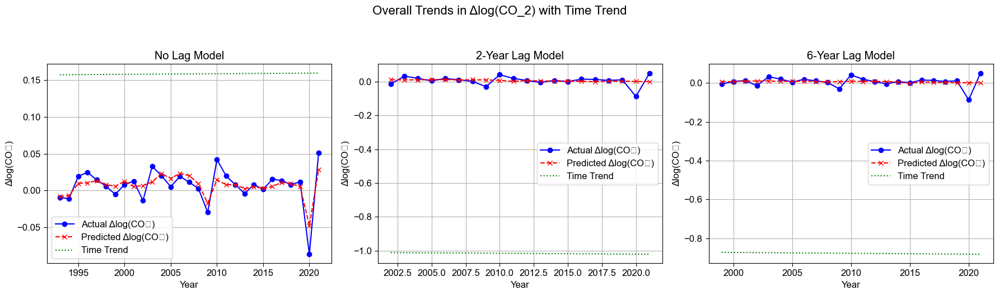

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns
fig.suptitle("Overall Trends in Δlog(CO_2) with Time Trend", fontsize=16, y=1.05)

# Function to plot trends for a given model
def plot_trends(ax, overall_trends, title):
    # Plot the actual CO₂ values
    ax.plot(overall_trends["Year"], overall_trends["actual_d_log_co2"], 
            label="Actual Δlog(CO₂)", color="blue", linestyle='-', marker='o')
    
    # Plot the predicted CO₂ values
    ax.plot(overall_trends["Year"], overall_trends["predicted_d_log_co2"], 
            label="Predicted Δlog(CO₂)", color="red", linestyle='--', marker='x')
    
    # Plot the time trend
    ax.plot(overall_trends["Year"], overall_trends["time_trend_values"], 
            label="Time Trend", color="green", linestyle=':', marker='')
    
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Δlog(CO₂)")
    ax.legend()
    ax.grid(True)

# --- No Lag Model ---
# Extract time trend and compute predictions
time_trend_coef_no_lag = model_fd_no_lag.params["time_trend"]
data_diff["time_trend_values_no_lag"] = time_trend_coef_no_lag * data_diff["time_trend"]
data_diff["pred_d_log_co2_no_lag"] = model_fd_no_lag.predict(data_diff)

# Aggregate trends for no lag model
overall_trends_no_lag = data_diff.groupby("Year").agg(
    actual_d_log_co2=("d_log_co2", "mean"),
    predicted_d_log_co2=("pred_d_log_co2_no_lag", "mean"),
    time_trend_values=("time_trend_values_no_lag", "mean")
).reset_index()

# Plot no lag model
plot_trends(axes[0], overall_trends_no_lag, "No Lag Model")

# --- 2-Year Lag Model ---
# Extract time trend and compute predictions
time_trend_coef_lag2 = model_fd_lag2.params["time_trend"]
data_diff_lag2["time_trend_values_lag2"] = time_trend_coef_lag2 * data_diff_lag2["time_trend"]
data_diff_lag2["pred_d_log_co2_lag2"] = model_fd_lag2.predict(data_diff_lag2)

# Aggregate trends for 2-year lag model
overall_trends_lag2 = data_diff_lag2.groupby("Year").agg(
    actual_d_log_co2=("d_log_co2", "mean"),
    predicted_d_log_co2=("pred_d_log_co2_lag2", "mean"),
    time_trend_values=("time_trend_values_lag2", "mean")
).reset_index()

# Plot 2-year lag model
plot_trends(axes[1], overall_trends_lag2, "2-Year Lag Model")

# --- 6-Year Lag Model ---
# Extract time trend and compute predictions
time_trend_coef_lag6 = model_fd_lag6.params["time_trend"]
data_diff_lag6["time_trend_values_lag6"] = time_trend_coef_lag6 * data_diff_lag6["time_trend"]
data_diff_lag6["pred_d_log_co2_lag6"] = model_fd_lag6.predict(data_diff_lag6)

# Aggregate trends for 6-year lag model
overall_trends_lag6 = data_diff_lag6.groupby("Year").agg(
    actual_d_log_co2=("d_log_co2", "mean"),
    predicted_d_log_co2=("pred_d_log_co2_lag6", "mean"),
    time_trend_values=("time_trend_values_lag6", "mean")
).reset_index()

# Plot 6-year lag model
plot_trends(axes[2], overall_trends_lag6, "6-Year Lag Model")

# Adjust layout and display
plt.tight_layout()
plt.show()

# Multiple Confounder Model

### DATA CLEANING:

In [71]:
output_model2 = os.path.join(base_path, "Cleaned data model_2")
os.makedirs(output_model2, exist_ok=True)  # Create the folder if it doesn't exist


In [72]:
##save FFelec to os

model_2_df_s= {"model_z_cip.csv":model_df ,
               'ffelec_cleaned.csv': ffelec_df}

for filename, df in model_2_df_s.items():
    df.to_csv(os.path.join(output_model2, filename), index=False)

print(f"All cleaned datasets saved to: {output_model2}")


All cleaned datasets saved to: /Users/amh/Desktop/CEU-EDP/DA4/Assignment/DA-4-2405060/Cleaned data model_2


In [73]:
output_model2 = os.path.join(base_path, "Cleaned data model_2")

# Load DataFrames
model_z_cip = pd.read_csv(os.path.join(output_model2, "model_z_cip.csv"))
ffelec_cleaned = pd.read_csv(os.path.join(output_model2, "ffelec_cleaned.csv"))

In [74]:
merged_df = model_z_cip.merge(ffelec_cleaned, on=["Year", "Code"], how="outer")


In [75]:
# Convert 'Year' to a numerical format (integer or float)
merged_df['Year'] = pd.to_numeric(merged_df['Year'], errors='coerce')
merged_df = merged_df[merged_df['Year'] >= 2000]
merged_df.describe()


,Year,val_cip,MVAsh,GDP_PPP,val_co2y,log_gdpy,log_co2y,d_log_co2,d_log_gdp,d_val_cip,time_trend,pred_log_co2,dlog_gdpy,dlog_co2y,dval_cip,FFelec_val
count,4973.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,4973.000000
mean,2011.197667,0.074691,0.127017,25393.158829,5.558471,9.596807,0.896918,0.006973,0.019416,-0.000635,2010.500000,0.896918,0.019416,0.006973,-0.000635,69.630247
std,6.749850,0.102283,0.059011,25453.848103,7.022216,1.144087,1.518442,0.094209,0.051491,0.006322,6.345342,1.538948,0.051491,0.094209,0.006322,343.981694
min,2000.000000,0.000000,0.004294,711.976394,0.021731,6.568045,-3.829014,-0.814149,-0.675855,-0.060332,2000.000000,-3.471274,-0.675855,-0.814149,-0.060332,0.000000
25%,2005.000000,0.010469,0.086053,6607.930953,0.998088,8.796026,-0.001914,-0.036186,0.001314,-0.001455,2005.000000,-0.024962,0.001314,-0.036186,-0.001455,0.260000
50%,2011.000000,0.030303,0.123909,15673.572922,3.373006,9.659731,1.215804,0.006131,0.021538,-0.000080,2010.500000,1.250881,0.021538,0.006131,-0.000080,2.550000
75%,2017.000000,0.088671,0.161821,37698.804372,7.716518,10.537384,2.043362,0.050935,0.042997,0.001058,2016.000000,2.093102,0.042997,0.050935,0.001058,25.960000
max,2023.000000,0.579437,0.402479,145591.019357,67.583840,11.888557,4.213369,0.790609,0.651186,0.059360,2021.000000,4.139662,0.651186,0.790609,0.059360,6122.630000


In [76]:
merged_df.tail()

,Year,val_cip,MVAsh,Code,GDP_PPP,val_co2y,log_gdpy,log_co2y,d_log_co2,d_log_gdp,d_val_cip,time_trend,pred_log_co2,dlog_gdpy,dlog_co2y,dval_cip,Country,FFelec_val
6064,2020,NaN,NaN,YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yemen,2.45
6065,2021,NaN,NaN,YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yemen,2.42
6066,2022,NaN,NaN,YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yemen,2.35
6067,2022,NaN,NaN,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zambia,2.16
6068,2022,NaN,NaN,ZWE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zimbabwe,2.92


In [77]:
mult_z_model = merged_df.dropna(subset=['GDP_PPP', 'val_co2y'])


In [78]:
mult_z_model.head()

,Year,val_cip,MVAsh,Code,GDP_PPP,val_co2y,log_gdpy,log_co2y,d_log_co2,d_log_gdp,d_val_cip,time_trend,pred_log_co2,dlog_gdpy,dlog_co2y,dval_cip,Country,FFelec_val
8,2000,0.003926,0.048536,AGO,6002.989140,0.987665,8.700013,-0.012412,-0.109306,-0.003034,0.000601,2000.0,-0.276736,-0.003034,-0.109306,0.000601,Angola,0.53
9,2001,0.003868,0.050686,AGO,6049.163212,0.949917,8.707675,-0.051380,-0.038968,0.007662,-0.000058,2001.0,-0.268974,0.007662,-0.038968,-0.000058,Angola,0.62
10,2002,0.003882,0.048104,AGO,6645.477766,0.927994,8.801692,-0.074730,-0.023350,0.094017,0.000015,2002.0,-0.242832,0.094017,-0.023350,0.000015,Angola,0.62
11,2003,0.003893,0.048346,AGO,6609.214889,0.974404,8.796220,-0.025929,0.048801,-0.005472,0.000011,2003.0,-0.230275,-0.005472,0.048801,0.000011,Angola,0.75
12,2004,0.004040,0.050970,AGO,7074.025947,0.914801,8.864185,-0.089049,-0.063119,0.067965,0.000147,2004.0,-0.198176,0.067965,-0.063119,0.000147,Angola,0.49


In [79]:
mult_z_model.describe()

,Year,val_cip,MVAsh,GDP_PPP,val_co2y,log_gdpy,log_co2y,d_log_co2,d_log_gdp,d_val_cip,time_trend,pred_log_co2,dlog_gdpy,dlog_co2y,dval_cip,FFelec_val
count,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000,3014.000000
mean,2010.500000,0.074691,0.127017,25393.158829,5.558471,9.596807,0.896918,0.006973,0.019416,-0.000635,2010.500000,0.896918,0.019416,0.006973,-0.000635,95.231586
std,6.345342,0.102283,0.059011,25453.848103,7.022216,1.144087,1.518442,0.094209,0.051491,0.006322,6.345342,1.538948,0.051491,0.094209,0.006322,402.338864
min,2000.000000,0.000000,0.004294,711.976394,0.021731,6.568045,-3.829014,-0.814149,-0.675855,-0.060332,2000.000000,-3.471274,-0.675855,-0.814149,-0.060332,0.000000
25%,2005.000000,0.010469,0.086053,6607.930953,0.998088,8.796026,-0.001914,-0.036186,0.001314,-0.001455,2005.000000,-0.024962,0.001314,-0.036186,-0.001455,1.200000
50%,2010.500000,0.030303,0.123909,15673.572922,3.373006,9.659731,1.215804,0.006131,0.021538,-0.000080,2010.500000,1.250881,0.021538,0.006131,-0.000080,6.270000
75%,2016.000000,0.088671,0.161821,37698.804372,7.716518,10.537384,2.043362,0.050935,0.042997,0.001058,2016.000000,2.093102,0.042997,0.050935,0.001058,43.615000
max,2021.000000,0.579437,0.402479,145591.019357,67.583840,11.888557,4.213369,0.790609,0.651186,0.059360,2021.000000,4.139662,0.651186,0.790609,0.059360,5678.030000


In [80]:
mult_z_model.columns

Index(['Year', 'val_cip', 'MVAsh', 'Code', 'GDP_PPP', 'val_co2y', 'log_gdpy',
       'log_co2y', 'd_log_co2', 'd_log_gdp', 'd_val_cip', 'time_trend',
       'pred_log_co2', 'dlog_gdpy', 'dlog_co2y', 'dval_cip', 'Country',
       'FFelec_val'],
      dtype='object')

### MODEL MULT CONFOUNDERS

In [81]:
# Filter data for the year 2005
cross_section_2005 = mult_z_model[mult_z_model["Year"] == 2005]

# Run cross-section OLS
model_cross_section = smf.ols("log_co2y ~ log_gdpy + val_cip + FFelec_val + MVAsh", data=cross_section_2005).fit()

# Print summary
print("\n--- Cross-Section OLS (2005) ---\n", model_cross_section.summary())


--- Cross-Section OLS (2005) ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     241.7
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           1.08e-59
Time:                        15:06:16   Log-Likelihood:                -115.07
No. Observations:                 137   AIC:                             240.1
Df Residuals:                     132   BIC:                             254.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.

In [82]:
# Create 2-year lagged differences for d_log_gdp and d_val_cip
mult_z_model["d_log_gdp_lag2"] = mult_z_model.groupby("Code")["d_log_gdp"].shift(2)
mult_z_model["d_val_cip_lag2"] = mult_z_model.groupby("Code")["d_val_cip"].shift(2)

# Create 2-year lagged differences for the new confounders
mult_z_model["d_FFelec_val_lag2"] = mult_z_model.groupby("Code")["FFelec_val"].shift(2)
mult_z_model["d_MVAsh_lag2"] = mult_z_model.groupby("Code")["MVAsh"].shift(2)

# Drop rows with missing lagged values
data_diff_lag2 = mult_z_model.dropna(subset=["d_log_gdp_lag2", "d_val_cip_lag2", "d_FFelec_val_lag2", "d_MVAsh_lag2"])

# Run the first difference model with 2-year lags and time trend
model_fd_lag2 = smf.ols("d_log_co2 ~ d_log_gdp_lag2 + d_val_cip_lag2 + d_FFelec_val_lag2 + d_MVAsh_lag2 + time_trend", data=data_diff_lag2).fit()

# Print summary
print("\n--- First Difference Model (2-Year Lags) ---\n", model_fd_lag2.summary())


--- First Difference Model (2-Year Lags) ---
                             OLS Regression Results                            
Dep. Variable:              d_log_co2   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.264
Date:                Sun, 16 Feb 2025   Prob (F-statistic):           0.000726
Time:                        15:06:16   Log-Likelihood:                 2563.2
No. Observations:                2740   AIC:                            -5114.
Df Residuals:                    2734   BIC:                            -5079.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [83]:
# Run fixed effects model with time and country fixed effects
model_fe = smf.ols("log_co2y ~ log_gdpy + val_cip + FFelec_val + MVAsh + C(Year) + C(Code)", data=mult_z_model).fit()

# Print summary
print("\n--- Fixed Effects Model (Time and Country FE) ---\n", model_fe.summary())


--- Fixed Effects Model (Time and Country FE) ---
                             OLS Regression Results                            
Dep. Variable:               log_co2y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1443.
Date:                Sun, 16 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:06:17   Log-Likelihood:                 1113.8
No. Observations:                3014   AIC:                            -1904.
Df Residuals:                    2852   BIC:                            -929.7
Df Model:                         161                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

### Visualisation



In [84]:

# Compute predictions from the fixed effects model
mult_z_model["pred_log_co2"] = model_fe.predict(mult_z_model)

# Get sorted unique country codes from the "Code" column
countries = sorted(mult_z_model["Code"].unique())
num_countries = len(countries)

# Use a pleasing palette (e.g., "tab20") and assign a unique color to each country
colors = sns.color_palette("tab20", num_countries)
color_map = dict(zip(countries, colors))

# Set up a grid of subplots (here, 4 columns)
cols = 4  
rows = math.ceil(num_countries / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

# Loop over each country, plot actual and predicted log CO₂ values over time
for i, code in enumerate(countries):
    ax = axes[i]
    # Filter and sort data for the current country by Year
    country_data = mult_z_model[mult_z_model["Code"] == code].sort_values("Year")
    
    # Plot the actual log CO₂ values (solid line with circle markers)
    ax.plot(country_data["Year"], country_data["log_co2y"], 
            label="Actual", color=color_map[code], linestyle='-', marker='o')
    # Plot the predicted log CO₂ values (dashed line with cross markers)
    ax.plot(country_data["Year"], country_data["pred_log_co2"], 
            label="Predicted", color=color_map[code], linestyle='--', marker='x')
    
    ax.set_title(code)
    ax.set_xlabel("Year")
    ax.set_ylabel("log(CO₂ per Capita)")
    ax.legend(fontsize=8)

# Remove any unused subplots if the grid has extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

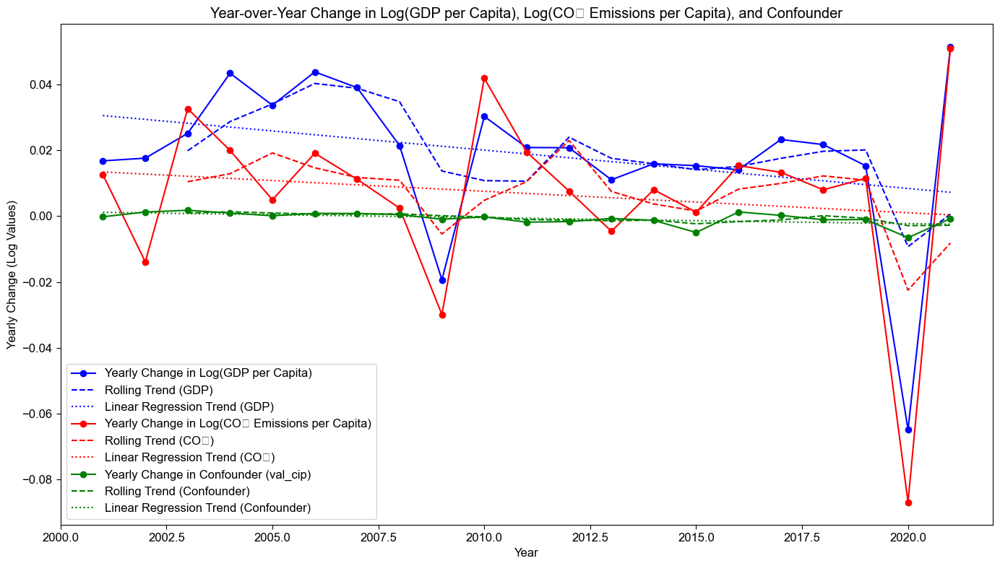

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression

# Calculate Year-over-Year (YoY) changes for log_gdpy, log_co2y, and val_cip
mult_z_model['dlog_gdpy'] = mult_z_model.groupby('Code')['log_gdpy'].diff()
mult_z_model['dlog_co2y'] = mult_z_model.groupby('Code')['log_co2y'].diff()
mult_z_model['dval_cip'] = mult_z_model.groupby('Code')['val_cip'].diff()  # YoY change for the confounder

# Group by Year and calculate the mean yearly change for each year
yearly_changes = mult_z_model.groupby('Year')[['dlog_gdpy', 'dlog_co2y', 'dval_cip']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 3  # You can adjust the window size (5 years as an example)
yearly_changes['rolling_trend_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_co2y'] = yearly_changes['dlog_co2y'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_cip'] = yearly_changes['dval_cip'].rolling(window=rolling_window).mean()  # Rolling trend for confounder

# --- Linear Regression Trend Line ---
# Aligning data to avoid misalignment issue
yearly_changes = yearly_changes.dropna(subset=['dlog_gdpy', 'dlog_co2y', 'dval_cip'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_gdpy = yearly_changes['dlog_gdpy']
y_co2y = yearly_changes['dlog_co2y']
y_cip = yearly_changes['dval_cip']  # Confounder

# Perform linear regression for all variables
reg_gdpy = LinearRegression().fit(X, y_gdpy)
reg_co2y = LinearRegression().fit(X, y_co2y)
reg_cip = LinearRegression().fit(X, y_cip)  # Regression for confounder

# Get the regression lines
yearly_changes['regression_trend_gdpy'] = reg_gdpy.predict(X)
yearly_changes['regression_trend_co2y'] = reg_co2y.predict(X)
yearly_changes['regression_trend_cip'] = reg_cip.predict(X)  # Regression trend for confounder

# Plotting the changes and trends
plt.figure(figsize=(14, 8))

# Plot the yearly change in log_gdpy
plt.plot(yearly_changes.index, yearly_changes['dlog_gdpy'], label="Yearly Change in Log(GDP per Capita)", color='blue', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_gdpy'], label="Rolling Trend (GDP)", color='blue', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_gdpy'], label="Linear Regression Trend (GDP)", color='blue', linestyle=':')

# Plot the yearly change in log_co2y
plt.plot(yearly_changes.index, yearly_changes['dlog_co2y'], label="Yearly Change in Log(CO₂ Emissions per Capita)", color='red', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_co2y'], label="Rolling Trend (CO₂)", color='red', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_co2y'], label="Linear Regression Trend (CO₂)", color='red', linestyle=':')

# Plot the yearly change in val_cip (confounder)
plt.plot(yearly_changes.index, yearly_changes['dval_cip'], label="Yearly Change in Confounder (val_cip)", color='green', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_cip'], label="Rolling Trend (Confounder)", color='green', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_cip'], label="Linear Regression Trend (Confounder)", color='green', linestyle=':')

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Yearly Change (Log Values)")
plt.title("Year-over-Year Change in Log(GDP per Capita), Log(CO₂ Emissions per Capita), and Confounder")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

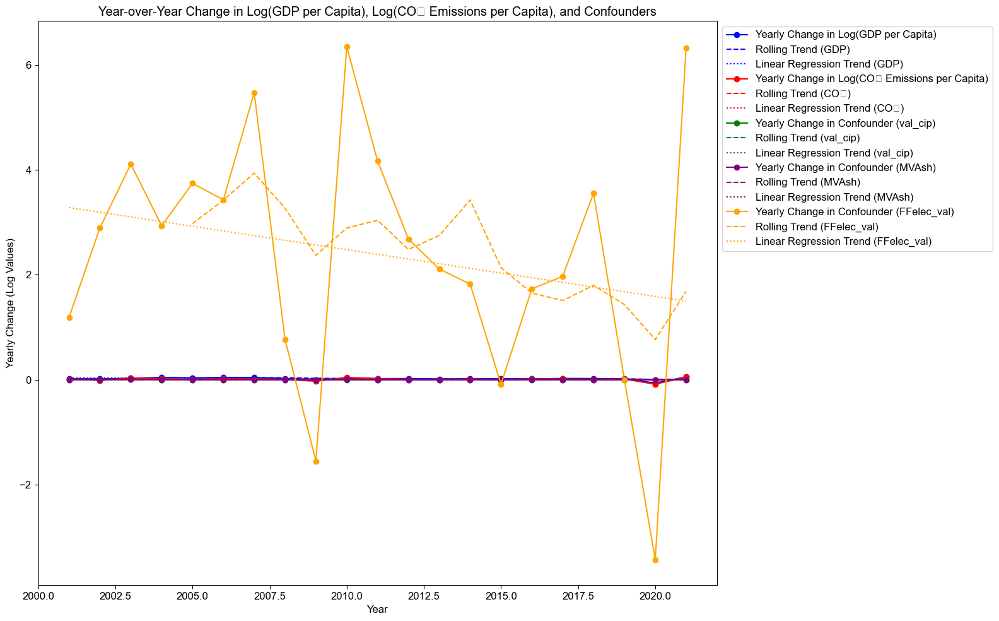

In [86]:

# Calculate Year-over-Year (YoY) changes for all variables
mult_z_model['dlog_gdpy'] = mult_z_model.groupby('Code')['log_gdpy'].diff()
mult_z_model['dlog_co2y'] = mult_z_model.groupby('Code')['log_co2y'].diff()
mult_z_model['dval_cip'] = mult_z_model.groupby('Code')['val_cip'].diff()  # YoY change for val_cip
mult_z_model['d_MVAsh'] = mult_z_model.groupby('Code')['MVAsh'].diff()  # YoY change for MVAsh
mult_z_model['d_FFelec_val'] = mult_z_model.groupby('Code')['FFelec_val'].diff()  # YoY change for FFelec_val

# Group by Year and calculate the mean yearly change for each year
yearly_changes = mult_z_model.groupby('Year')[['dlog_gdpy', 'dlog_co2y', 'dval_cip', 'd_MVAsh', 'd_FFelec_val']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 5  # You can adjust the window size (5 years as an example)
yearly_changes['rolling_trend_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_co2y'] = yearly_changes['dlog_co2y'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_cip'] = yearly_changes['dval_cip'].rolling(window=rolling_window).mean()  # Rolling trend for val_cip
yearly_changes['rolling_trend_MVAsh'] = yearly_changes['d_MVAsh'].rolling(window=rolling_window).mean()  # Rolling trend for MVAsh
yearly_changes['rolling_trend_FFelec_val'] = yearly_changes['d_FFelec_val'].rolling(window=rolling_window).mean()  # Rolling trend for FFelec_val

# --- Linear Regression Trend Line ---
# Aligning data to avoid misalignment issue
yearly_changes = yearly_changes.dropna(subset=['dlog_gdpy', 'dlog_co2y', 'dval_cip', 'd_MVAsh', 'd_FFelec_val'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_gdpy = yearly_changes['dlog_gdpy']
y_co2y = yearly_changes['dlog_co2y']
y_cip = yearly_changes['dval_cip']  # Confounder: val_cip
y_MVAsh = yearly_changes['d_MVAsh']  # Confounder: MVAsh
y_FFelec_val = yearly_changes['d_FFelec_val']  # Confounder: FFelec_val

# Perform linear regression for all variables
reg_gdpy = LinearRegression().fit(X, y_gdpy)
reg_co2y = LinearRegression().fit(X, y_co2y)
reg_cip = LinearRegression().fit(X, y_cip)  # Regression for val_cip
reg_MVAsh = LinearRegression().fit(X, y_MVAsh)  # Regression for MVAsh
reg_FFelec_val = LinearRegression().fit(X, y_FFelec_val)  # Regression for FFelec_val

# Get the regression lines
yearly_changes['regression_trend_gdpy'] = reg_gdpy.predict(X)
yearly_changes['regression_trend_co2y'] = reg_co2y.predict(X)
yearly_changes['regression_trend_cip'] = reg_cip.predict(X)  # Regression trend for val_cip
yearly_changes['regression_trend_MVAsh'] = reg_MVAsh.predict(X)  # Regression trend for MVAsh
yearly_changes['regression_trend_FFelec_val'] = reg_FFelec_val.predict(X)  # Regression trend for FFelec_val

# Plotting the changes and trends
plt.figure(figsize=(16, 10))

# Plot the yearly change in log_gdpy
plt.plot(yearly_changes.index, yearly_changes['dlog_gdpy'], label="Yearly Change in Log(GDP per Capita)", color='blue', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_gdpy'], label="Rolling Trend (GDP)", color='blue', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_gdpy'], label="Linear Regression Trend (GDP)", color='blue', linestyle=':')

# Plot the yearly change in log_co2y
plt.plot(yearly_changes.index, yearly_changes['dlog_co2y'], label="Yearly Change in Log(CO₂ Emissions per Capita)", color='red', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_co2y'], label="Rolling Trend (CO₂)", color='red', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_co2y'], label="Linear Regression Trend (CO₂)", color='red', linestyle=':')

# Plot the yearly change in val_cip (confounder)
plt.plot(yearly_changes.index, yearly_changes['dval_cip'], label="Yearly Change in Confounder (val_cip)", color='green', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_cip'], label="Rolling Trend (val_cip)", color='green', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_cip'], label="Linear Regression Trend (val_cip)", color='green', linestyle=':')

# Plot the yearly change in MVAsh (confounder)
plt.plot(yearly_changes.index, yearly_changes['d_MVAsh'], label="Yearly Change in Confounder (MVAsh)", color='purple', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_MVAsh'], label="Rolling Trend (MVAsh)", color='purple', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_MVAsh'], label="Linear Regression Trend (MVAsh)", color='purple', linestyle=':')

# Plot the yearly change in FFelec_val (confounder)
plt.plot(yearly_changes.index, yearly_changes['d_FFelec_val'], label="Yearly Change in Confounder (FFelec_val)", color='orange', marker='o')
plt.plot(yearly_changes.index, yearly_changes['rolling_trend_FFelec_val'], label="Rolling Trend (FFelec_val)", color='orange', linestyle='--')
plt.plot(yearly_changes.index, yearly_changes['regression_trend_FFelec_val'], label="Linear Regression Trend (FFelec_val)", color='orange', linestyle=':')

# Add labels, title, and legend
plt.xlabel("Year")
plt.ylabel("Yearly Change (Log Values)")
plt.title("Year-over-Year Change in Log(GDP per Capita), Log(CO₂ Emissions per Capita), and Confounders")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the plot

# Show the plot
plt.tight_layout()
plt.show()

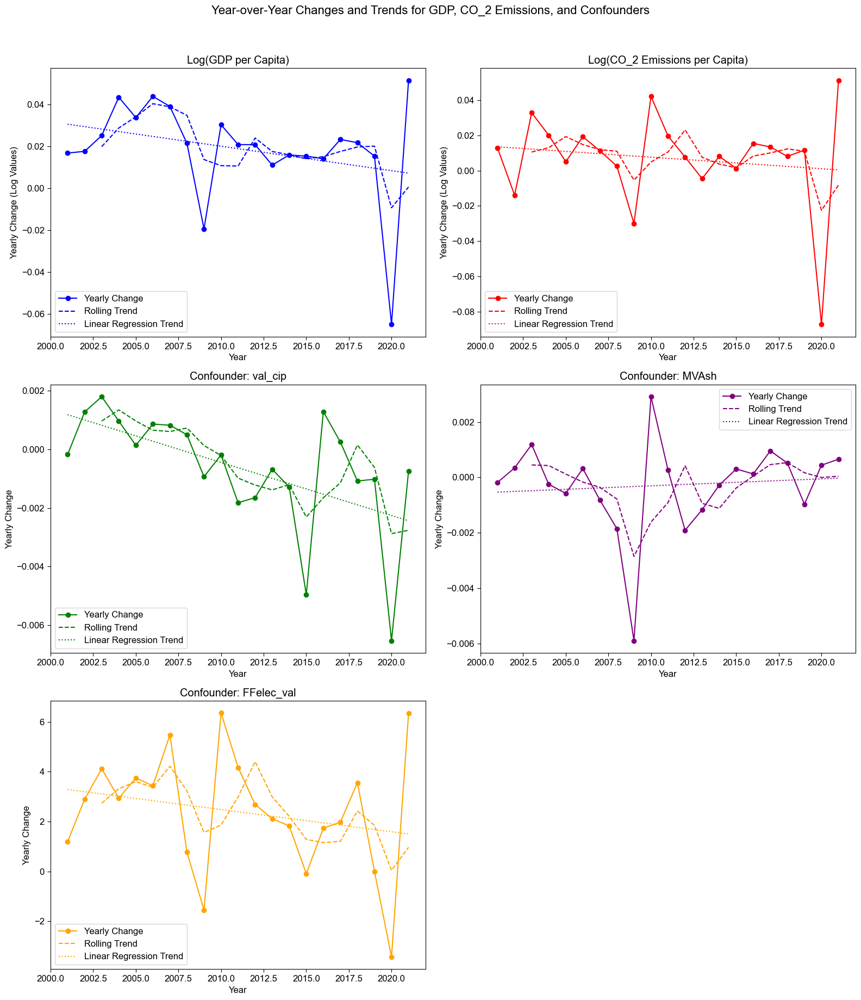

In [94]:
# Calculate Year-over-Year (YoY) changes for all variables
mult_z_model['dlog_gdpy'] = mult_z_model.groupby('Code')['log_gdpy'].diff()
mult_z_model['dlog_co2y'] = mult_z_model.groupby('Code')['log_co2y'].diff()
mult_z_model['dval_cip'] = mult_z_model.groupby('Code')['val_cip'].diff()  # YoY change for val_cip
mult_z_model['d_MVAsh'] = mult_z_model.groupby('Code')['MVAsh'].diff()  # YoY change for MVAsh
mult_z_model['d_FFelec_val'] = mult_z_model.groupby('Code')['FFelec_val'].diff()  # YoY change for FFelec_val

# Group by Year and calculate the mean yearly change for each year
yearly_changes = mult_z_model.groupby('Year')[['dlog_gdpy', 'dlog_co2y', 'dval_cip', 'd_MVAsh', 'd_FFelec_val']].mean()

# --- Rolling Mean Trend (Smoothing) ---
rolling_window = 3  # You can adjust the window size (5 years as an example)
yearly_changes['rolling_trend_gdpy'] = yearly_changes['dlog_gdpy'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_co2y'] = yearly_changes['dlog_co2y'].rolling(window=rolling_window).mean()
yearly_changes['rolling_trend_cip'] = yearly_changes['dval_cip'].rolling(window=rolling_window).mean()  # Rolling trend for val_cip
yearly_changes['rolling_trend_MVAsh'] = yearly_changes['d_MVAsh'].rolling(window=rolling_window).mean()  # Rolling trend for MVAsh
yearly_changes['rolling_trend_FFelec_val'] = yearly_changes['d_FFelec_val'].rolling(window=rolling_window).mean()  # Rolling trend for FFelec_val

# --- Linear Regression Trend Line ---
# Aligning data to avoid misalignment issue
yearly_changes = yearly_changes.dropna(subset=['dlog_gdpy', 'dlog_co2y', 'dval_cip', 'd_MVAsh', 'd_FFelec_val'])

# Prepare the data for linear regression
X = yearly_changes.index.values.reshape(-1, 1)  # Reshape for linear regression
y_gdpy = yearly_changes['dlog_gdpy']
y_co2y = yearly_changes['dlog_co2y']
y_cip = yearly_changes['dval_cip']  # Confounder: val_cip
y_MVAsh = yearly_changes['d_MVAsh']  # Confounder: MVAsh
y_FFelec_val = yearly_changes['d_FFelec_val']  # Confounder: FFelec_val

# Perform linear regression for all variables
reg_gdpy = LinearRegression().fit(X, y_gdpy)
reg_co2y = LinearRegression().fit(X, y_co2y)
reg_cip = LinearRegression().fit(X, y_cip)  # Regression for val_cip
reg_MVAsh = LinearRegression().fit(X, y_MVAsh)  # Regression for MVAsh
reg_FFelec_val = LinearRegression().fit(X, y_FFelec_val)  # Regression for FFelec_val

# Get the regression lines
yearly_changes['regression_trend_gdpy'] = reg_gdpy.predict(X)
yearly_changes['regression_trend_co2y'] = reg_co2y.predict(X)
yearly_changes['regression_trend_cip'] = reg_cip.predict(X)  # Regression trend for val_cip
yearly_changes['regression_trend_MVAsh'] = reg_MVAsh.predict(X)  # Regression trend for MVAsh
yearly_changes['regression_trend_FFelec_val'] = reg_FFelec_val.predict(X)  # Regression trend for FFelec_val

# --- Plotting in Subplot Grid ---
fig, axes = plt.subplots(3, 2, figsize=(16, 18))  # 3 rows, 2 columns
fig.suptitle("Year-over-Year Changes and Trends for GDP, CO_2 Emissions, and Confounders", fontsize=16, y=1.02)


# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot for log_gdpy
ax = axes[0]
ax.plot(yearly_changes.index, yearly_changes['dlog_gdpy'], label="Yearly Change", color='blue', marker='o')
ax.plot(yearly_changes.index, yearly_changes['rolling_trend_gdpy'], label="Rolling Trend", color='blue', linestyle='--')
ax.plot(yearly_changes.index, yearly_changes['regression_trend_gdpy'], label="Linear Regression Trend", color='blue', linestyle=':')
ax.set_title("Log(GDP per Capita)")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Change (Log Values)")
ax.legend()

# Plot for log_co2y
ax = axes[1]
ax.plot(yearly_changes.index, yearly_changes['dlog_co2y'], label="Yearly Change", color='red', marker='o')
ax.plot(yearly_changes.index, yearly_changes['rolling_trend_co2y'], label="Rolling Trend", color='red', linestyle='--')
ax.plot(yearly_changes.index, yearly_changes['regression_trend_co2y'], label="Linear Regression Trend", color='red', linestyle=':')
ax.set_title("Log(CO_2 Emissions per Capita)")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Change (Log Values)")
ax.legend()

# Plot for val_cip
ax = axes[2]
ax.plot(yearly_changes.index, yearly_changes['dval_cip'], label="Yearly Change", color='green', marker='o')
ax.plot(yearly_changes.index, yearly_changes['rolling_trend_cip'], label="Rolling Trend", color='green', linestyle='--')
ax.plot(yearly_changes.index, yearly_changes['regression_trend_cip'], label="Linear Regression Trend", color='green', linestyle=':')
ax.set_title("Confounder: val_cip")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Change")
ax.legend()

# Plot for MVAsh
ax = axes[3]
ax.plot(yearly_changes.index, yearly_changes['d_MVAsh'], label="Yearly Change", color='purple', marker='o')
ax.plot(yearly_changes.index, yearly_changes['rolling_trend_MVAsh'], label="Rolling Trend", color='purple', linestyle='--')
ax.plot(yearly_changes.index, yearly_changes['regression_trend_MVAsh'], label="Linear Regression Trend", color='purple', linestyle=':')
ax.set_title("Confounder: MVAsh")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Change")
ax.legend()

# Plot for FFelec_val
ax = axes[4]
ax.plot(yearly_changes.index, yearly_changes['d_FFelec_val'], label="Yearly Change", color='orange', marker='o')
ax.plot(yearly_changes.index, yearly_changes['rolling_trend_FFelec_val'], label="Rolling Trend", color='orange', linestyle='--')
ax.plot(yearly_changes.index, yearly_changes['regression_trend_FFelec_val'], label="Linear Regression Trend", color='orange', linestyle=':')
ax.set_title("Confounder: FFelec_val")
ax.set_xlabel("Year")
ax.set_ylabel("Yearly Change")
ax.legend()

# Remove the empty subplot (if any)
fig.delaxes(axes[5])

# Adjust layout and display
plt.tight_layout()
plt.show()

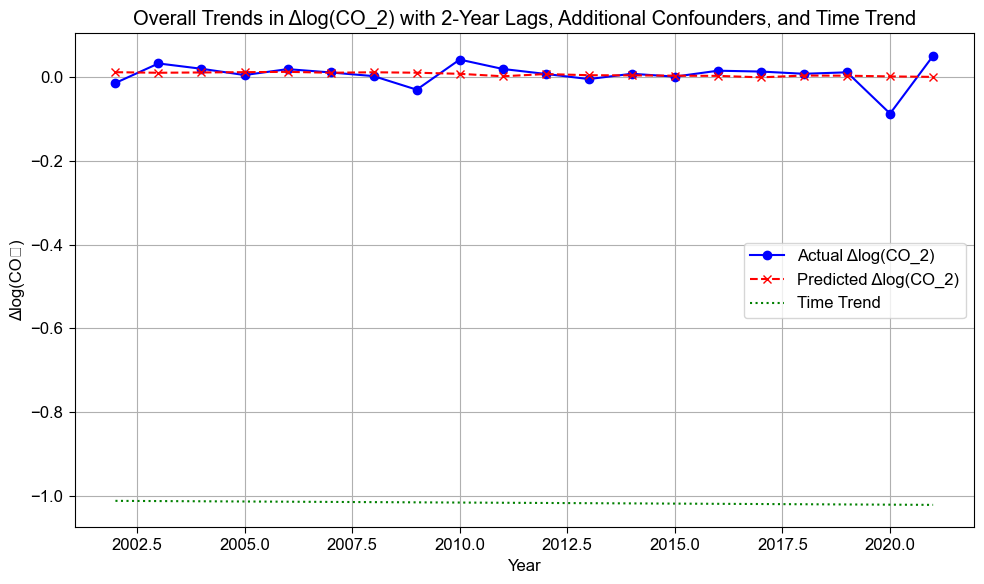

In [88]:
# Extract the time trend coefficient from the regression model
time_trend_coef = model_fd_lag2.params["time_trend"]

# Create a time trend variable for plotting
data_diff_lag2["time_trend_values"] = time_trend_coef * data_diff_lag2["time_trend"]

# Compute predicted values from the regression model
data_diff_lag2["pred_d_log_co2"] = model_fd_lag2.predict(data_diff_lag2)

# Aggregate the actual and predicted CO₂ values by Year
overall_trends_lag2 = data_diff_lag2.groupby("Year").agg(
    actual_d_log_co2=("d_log_co2", "mean"),
    predicted_d_log_co2=("pred_d_log_co2", "mean"),
    time_trend_values=("time_trend_values", "mean")
).reset_index()

# Plot the overall trends
plt.figure(figsize=(10, 6))

# Plot the actual CO₂ values (solid line with circle markers)
plt.plot(overall_trends_lag2["Year"], overall_trends_lag2["actual_d_log_co2"], 
         label="Actual Δlog(CO_2)", color="blue", linestyle='-', marker='o')

# Plot the predicted CO₂ values (dashed line with cross markers)
plt.plot(overall_trends_lag2["Year"], overall_trends_lag2["predicted_d_log_co2"], 
         label="Predicted Δlog(CO_2)", color="red", linestyle='--', marker='x')

# Plot the time trend (dotted line)
plt.plot(overall_trends_lag2["Year"], overall_trends_lag2["time_trend_values"], 
         label="Time Trend", color="green", linestyle=':', marker='')

plt.title("Overall Trends in Δlog(CO_2) with 2-Year Lags, Additional Confounders, and Time Trend")
plt.xlabel("Year")
plt.ylabel("Δlog(CO₂)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [93]:
mult_z_model['Country'].nunique()

137